In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
df = pd.read_csv('../data/mall-customer/Mall_Customers.csv')

df.shape


(200, 5)

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# Standardize (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by component: {explained_variance}')

Explained variance by component: [0.44266167 0.33308378]


In [11]:
# --- Explained Variance ---
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance Ratio per component:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.2f}%)  |  Cumulative: {cv*100:.2f}%")

Explained Variance Ratio per component:
  PC1: 0.4427 (44.27%)  |  Cumulative: 44.27%
  PC2: 0.3331 (33.31%)  |  Cumulative: 77.57%
  PC3: 0.2243 (22.43%)  |  Cumulative: 100.00%


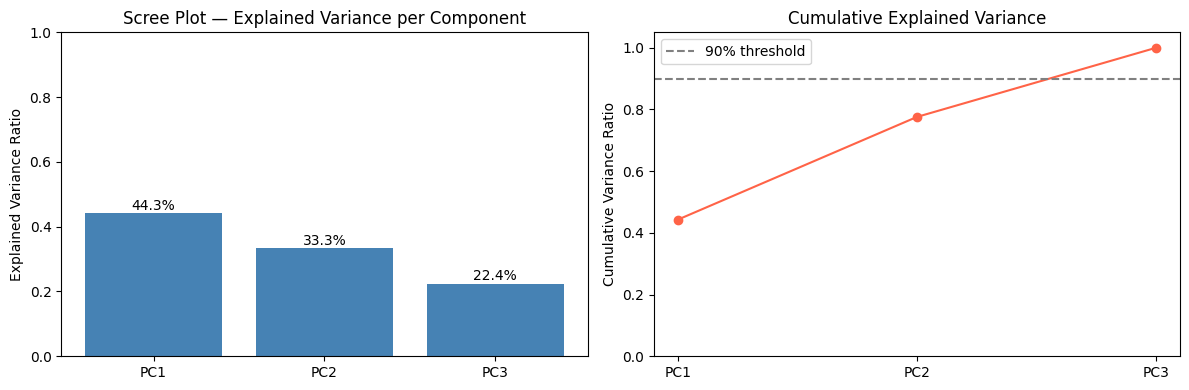

In [12]:
# --- Scree Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

components = [f'PC{i+1}' for i in range(len(explained_var))]

axes[0].bar(components, explained_var, color='steelblue')
axes[0].set_title('Scree Plot — Explained Variance per Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_ylim(0, 1)
for i, v in enumerate(explained_var):
    axes[0].text(i, v + 0.01, f'{v*100:.1f}%', ha='center')

axes[1].plot(components, cumulative_var, marker='o', color='tomato')
axes[1].axhline(y=0.90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# --- Loadings / Component Matrix ---
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print("\nPCA Loadings (contribution of each feature to each PC):")
print(loadings.round(4))


PCA Loadings (contribution of each feature to each PC):
                           PC1     PC2     PC3
Age                     0.7064  0.0301  0.7072
Annual Income (k$)     -0.0480  0.9988  0.0054
Spending Score (1-100) -0.7062 -0.0378  0.7070


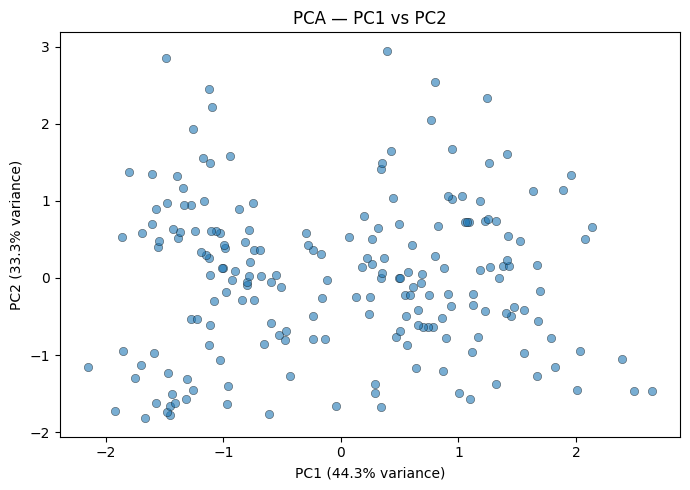

In [14]:
# --- 2D scatter plot of PC1 vs PC2 ---
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, edgecolors='k', linewidths=0.4)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.title('PCA — PC1 vs PC2')
plt.tight_layout()
plt.show()

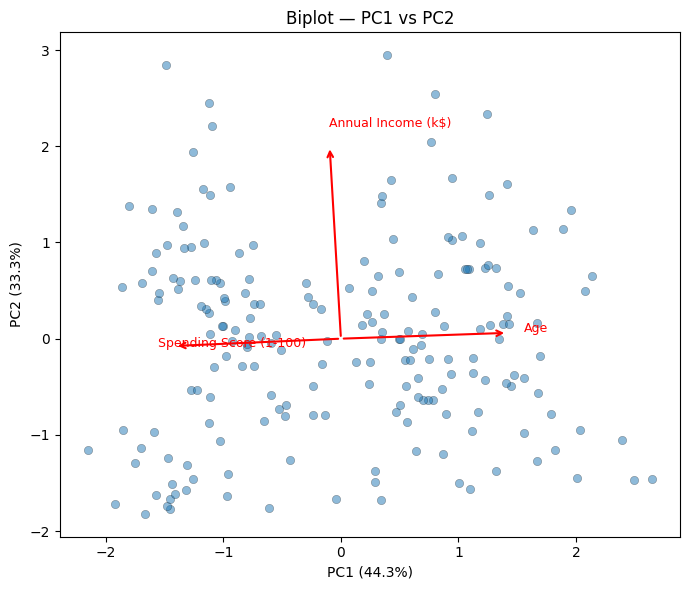

In [15]:
# --- Biplot: data points + feature vectors ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, edgecolors='k', linewidths=0.3)

# Draw loading arrows
for i, feat in enumerate(features):
    ax.annotate('', xy=(pca.components_[0, i]*2, pca.components_[1, i]*2),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text(pca.components_[0, i]*2.2, pca.components_[1, i]*2.2, feat,
            color='red', fontsize=9)

ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
ax.set_title('Biplot — PC1 vs PC2')
plt.tight_layout()
plt.show()